In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("SuperStoreOrders.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:\n")
print(df.columns)

print("\nDataset Information:\n")
print(df.info())

Shape of Dataset: (51290, 21)

Column Names:

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region 

In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [ ]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [ ]:
# Convert mixed date formats

df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)

In [ ]:
# Create Month-Year column

df['Month_Year'] = df['order_date'].dt.to_period('M')

TypeError: no numeric data to plot

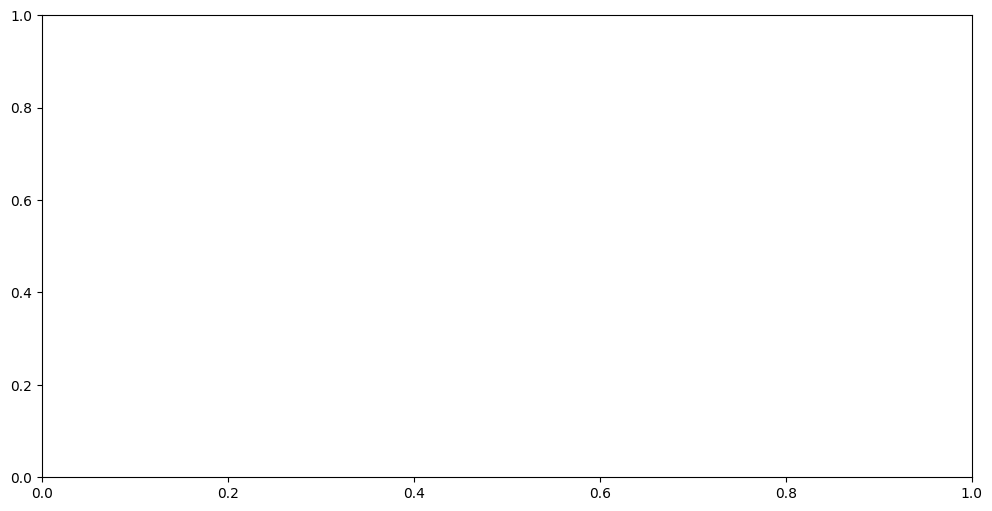

In [ ]:
# Monthly Sales Trend

monthly_sales = df.groupby('Month_Year')['sales'].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")

plt.show()

In [ ]:
# Convert sales column to numeric

df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [ ]:
print(df['sales'].dtype)

float64


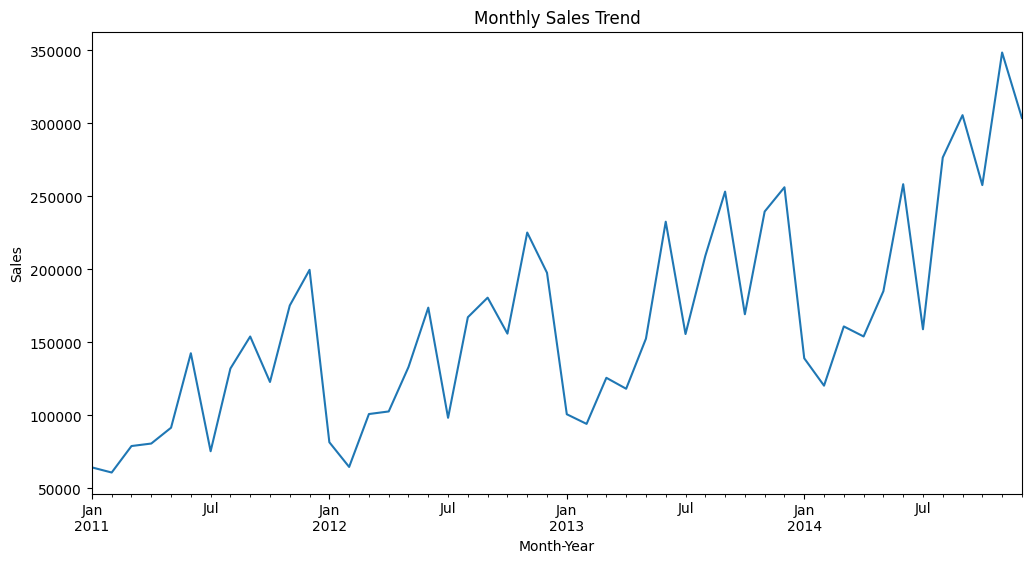

In [ ]:
# Monthly Sales Trend

monthly_sales = df.groupby('Month_Year')['sales'].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")

plt.show()

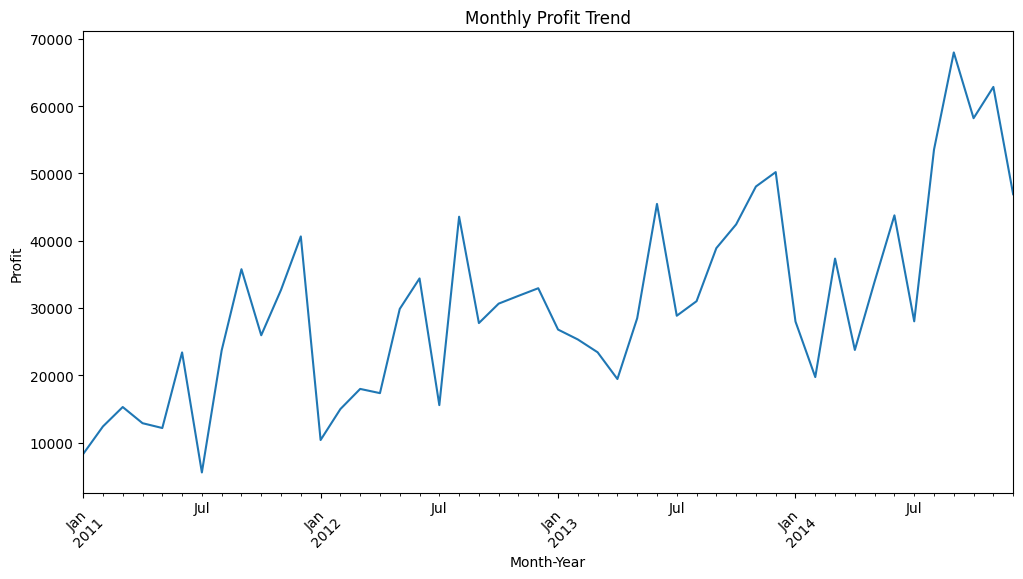

In [18]:
monthly_profit = df.groupby('Month_Year')['profit'].sum()

plt.figure(figsize=(12,6))

monthly_profit.plot()

plt.title("Monthly Profit Trend")
plt.xlabel("Month-Year")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

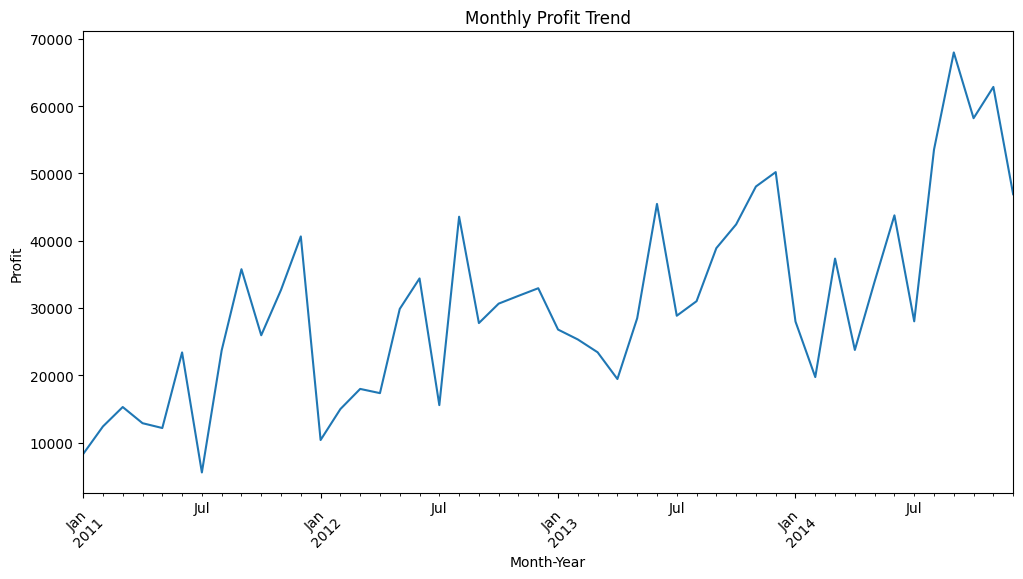

In [19]:
monthly_profit = df.groupby('Month_Year')['profit'].sum()

plt.figure(figsize=(12,6))

monthly_profit.plot()

plt.title("Monthly Profit Trend")
plt.xlabel("Month-Year")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

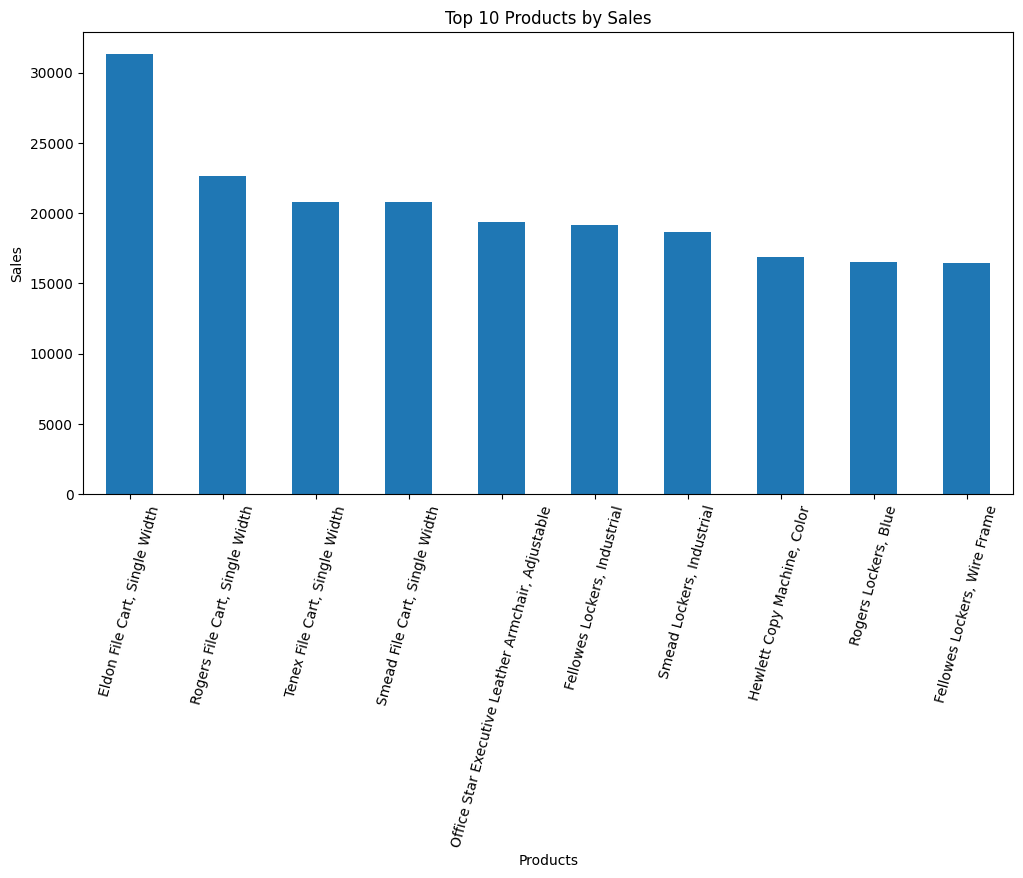

In [20]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Products")
plt.ylabel("Sales")

plt.xticks(rotation=75)

plt.show()

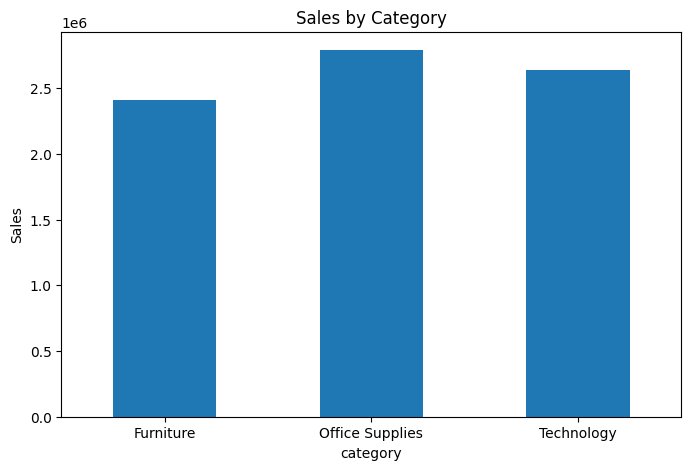

In [21]:
category_sales = df.groupby('category')['sales'].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

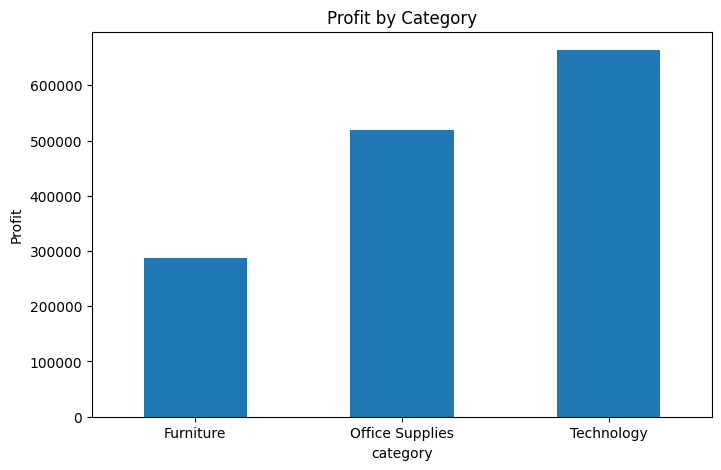

In [22]:
category_profit = df.groupby('category')['profit'].sum()

plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title("Profit by Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

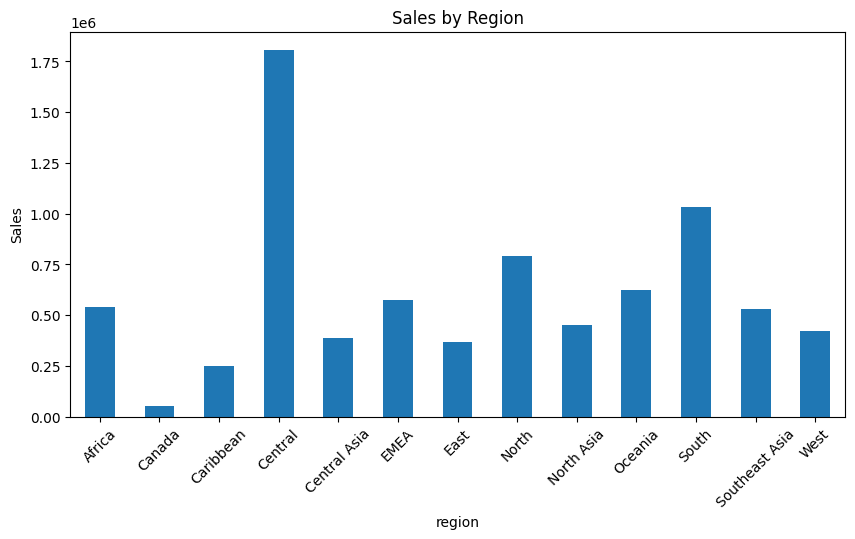

In [23]:
region_sales = df.groupby('region')['sales'].sum()

plt.figure(figsize=(10,5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

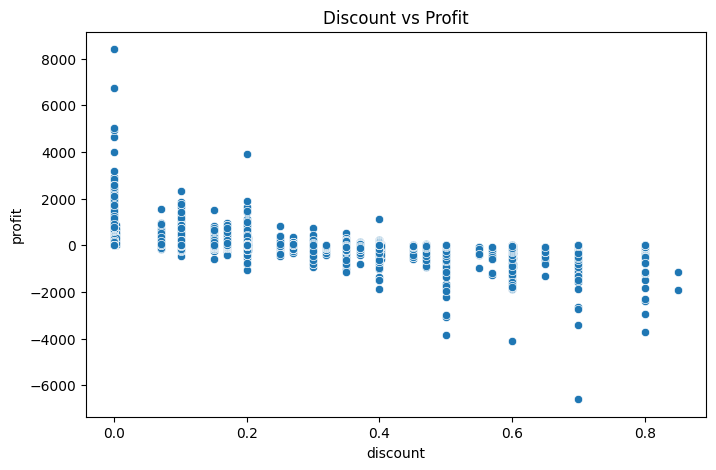

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='discount', y='profit', data=df)

plt.title("Discount vs Profit")

plt.show()

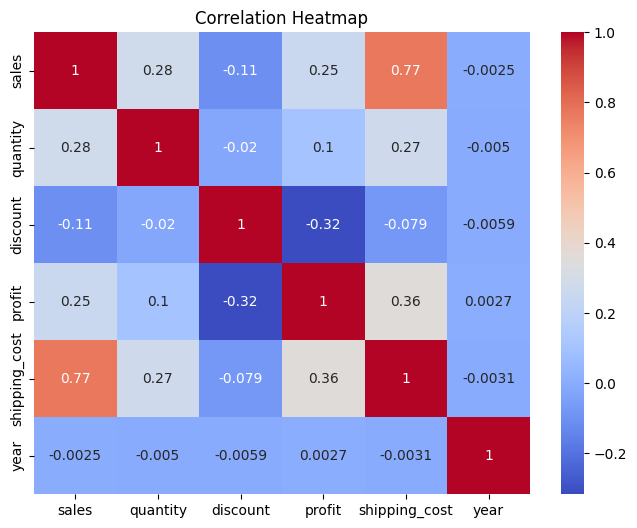

In [25]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Conclusion

This project analyzed Superstore sales data to identify revenue trends, product performance, regional sales patterns, and profitability factors.

Key Findings:

Sales showed fluctuations across different months.
Certain products generated significantly higher revenue.
Product categories contributed differently to overall profit.
Regional performance varied across markets.
Higher discounts negatively affected profitability in many cases.

The project successfully demonstrated data cleaning, exploratory data analysis, data visualization, and business insight generation using Python.